# NB0 — EDA & Data Preparation  ·  `eda-and-data-prep`

**Course:** CSE 438 — Digital Image Processing · **Dept.** of Computer Science & Engineering, East West University
**Instructor:** _`<fill instructor>`_ · **Term:** Summer 2026

**Group:** _`<fill group number/name>`_
**Members:**
| # | Name | Student ID |
|---|---|---|
| 1 | MD. Asif Hossain | 2022-3-60-007 |
| 2 | _`<member 2>`_ | _`<id>`_ |
| 3 | _`<member 3>`_ | _`<id>`_ |
| 4 | _`<member 4>`_ | _`<id>`_ |

**Assigned dataset:** *PaveCrack1300 — A UAV-Acquired Pavement Crack Segmentation Dataset*
(1,300 image–mask pairs · 512×512 · binary: background / crack · Mendeley DOI 10.17632/8b27pdcxv7 · CC BY 4.0).

---
### Purpose of this notebook (Tasks A–D)
This is **Notebook 0 of 4**. It produces the single, leakage-safe data split that **all three model
notebooks reuse**, so the benchmark is fair.

| Task | What we do here |
|---|---|
| **A — EDA** | pixel-level class distribution, size/aspect distribution, representative pairs, corrupt / mismatch / near-duplicate checks, imbalance summary |
| **B — Leakage-safe split** | derive empirical groups (dHash near-dup clustering), stratified 70/15/15 split (seed 42), assert zero overlap, **save `split.json`** |
| **C — Augmentation** | Albumentations pipeline (train-only, synchronized image+mask), every transform justified |
| **D — Sanity check** | post-augmentation grid (image \| mask \| overlay) — the required quality gate before any training |

**Downstream contract:** after running end-to-end, **Save Version (Commit)**. The `/kaggle/working`
outputs (`split.json`, `class_weights.json`, `manifest.csv`) become a Dataset that NB1–NB3 attach via
**+ Add Input** and load name-agnostically with `glob`.

## 1 · Setup, imports & reproducibility
All hyperparameters and dataset constants live in the **CONFIG** block so every downstream choice is
traceable to one place. `SEED = 42` is fixed and every RNG is seeded for a fully reproducible split.

In [1]:
import os, re, glob, json, random, sys, time, hashlib, warnings
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
warnings.filterwarnings("ignore")

# ---- version pins (report for reproducibility) ----
import matplotlib, PIL
print("numpy      :", np.__version__)
print("pandas     :", pd.__version__)
print("matplotlib :", matplotlib.__version__)
print("Pillow     :", PIL.__version__)
print("opencv     :", cv2.__version__)

# ---- Albumentations (synchronized image+mask transforms) ----
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except Exception:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "albumentations"], check=False)
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
print("albumentations:", A.__version__)

# ============================ CONFIG ============================
SEED          = 42
NUM_CLASSES   = 2
CLASS_NAMES   = ["background", "crack"]
MASK_VALUE_MAP = {0: 0, 255: 1}          # raw PNG pixel value -> class id
IMG_SIZE      = 512                      # native, uniform
SPLIT_RATIOS  = (0.70, 0.15, 0.15)       # train / val / test
N_STRATA      = 5                        # crack-density strata for balanced splitting
DHASH_SIZE    = 8                        # -> 64-bit perceptual hash
DUP_HAMMING   = 6                        # <= this Hamming distance => near-duplicate (same group)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
WORK          = Path("/kaggle/working")
# ===============================================================

def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
seed_everything()
print("\nConfig loaded. SEED =", SEED, "| classes =", CLASS_NAMES)

numpy      : 2.0.2
pandas     : 2.3.3
matplotlib : 3.10.0
Pillow     : 11.3.0
opencv     : 4.13.0
albumentations: 2.0.8

Config loaded. SEED = 42 | classes = ['background', 'crack']


## 2 · Dataset discovery (name-agnostic)
The dataset mounts under a nested, space-containing path, so we discover files with a **recursive glob**
(`/kaggle/input/**/images/images/*.jpg`) rather than hard-coding a path. Every image is paired to its
mask by the shared `crack_XXXX` stem, and we merge in `sample_metadata.csv`.

In [2]:
def find_dataset():
    imgs = sorted(glob.glob("/kaggle/input/**/images/images/*.jpg", recursive=True))
    if not imgs:  # robustness fallbacks
        imgs = sorted(glob.glob("/kaggle/input/**/images/**/*.jpg", recursive=True))
    if not imgs:
        imgs = [p for p in glob.glob("/kaggle/input/**/*.jpg", recursive=True) if "mask" not in p.lower()]
    assert imgs, "No .jpg images found under /kaggle/input — is the PaveCrack1300 dataset attached?"
    # map each image -> its mask (same stem, .png, under masks/masks)
    all_masks = glob.glob("/kaggle/input/**/masks/**/*.png", recursive=True)
    mask_by_stem = {Path(m).stem: m for m in all_masks}
    rows = []
    for ip in imgs:
        stem = Path(ip).stem
        mp = mask_by_stem.get(stem)
        rows.append(dict(sample_id=stem, image_path=ip, mask_path=mp))
    return pd.DataFrame(rows)

df = find_dataset()
print("images discovered :", len(df))
print("masks matched     :", df.mask_path.notna().sum())
assert df.mask_path.notna().all(), "Some images have no matching mask!"

# merge official metadata
meta_csv = glob.glob("/kaggle/input/**/sample_metadata.csv", recursive=True)
if meta_csv:
    meta = pd.read_csv(meta_csv[0])
    df = df.merge(meta, on="sample_id", how="left")
    print("metadata merged   :", meta.shape, "->", list(meta.columns))
else:
    print("WARNING: sample_metadata.csv not found; will compute crack ratios from masks.")
df.head()

images discovered : 1300
masks matched     : 1300
metadata merged   : (1300, 9) -> ['sample_id', 'image_file', 'mask_file', 'image_width', 'image_height', 'crack_pixel_ratio', 'crack_pixel_count', 'weather', 'time_of_day']


,sample_id,image_path,mask_path,image_file,mask_file,image_width,image_height,crack_pixel_ratio,crack_pixel_count,weather,time_of_day
0,crack_0001,/kaggle/input/datasets/mantashamahi/pavecrack1...,/kaggle/input/datasets/mantashamahi/pavecrack1...,crack_0001.jpg,crack_0001.png,512,512,11.6390,5840,clear,daytime
1,crack_0002,/kaggle/input/datasets/mantashamahi/pavecrack1...,/kaggle/input/datasets/mantashamahi/pavecrack1...,crack_0002.jpg,crack_0002.png,512,512,5.7059,2863,clear,daytime
2,crack_0003,/kaggle/input/datasets/mantashamahi/pavecrack1...,/kaggle/input/datasets/mantashamahi/pavecrack1...,crack_0003.jpg,crack_0003.png,512,512,6.2221,3122,clear,daytime
3,crack_0004,/kaggle/input/datasets/mantashamahi/pavecrack1...,/kaggle/input/datasets/mantashamahi/pavecrack1...,crack_0004.jpg,crack_0004.png,512,512,14.4850,7268,clear,daytime
4,crack_0005,/kaggle/input/datasets/mantashamahi/pavecrack1...,/kaggle/input/datasets/mantashamahi/pavecrack1...,crack_0005.jpg,crack_0005.png,512,512,13.2175,6632,clear,daytime


## 3 · Task A — Exploratory Data Analysis

### 3.1  Verify mask encoding
We confirm masks are single-channel with values in **{0, 255}** and define the remap **255 → 1** used
everywhere downstream. A bug here (e.g. an unexpected value, or an RGB mask) would silently corrupt every
label, so we assert it.

In [3]:
bad, seen_vals = [], set()
for mp in df.mask_path.sample(min(200, len(df)), random_state=SEED):
    m = np.array(Image.open(mp))
    if m.ndim != 2:
        bad.append((mp, "not single-channel"))
    seen_vals.update(np.unique(m).tolist())
print("distinct mask values across 200-mask sample :", sorted(seen_vals))
assert seen_vals.issubset({0, 255}), f"Unexpected mask values: {seen_vals}"
assert not bad, bad[:5]
print("OK — masks are single-channel binary {0,255}. Remap 255 -> class 1 (crack).")

distinct mask values across 200-mask sample : [0, 255]
OK — masks are single-channel binary {0,255}. Remap 255 -> class 1 (crack).


### 3.2  Pixel-level class distribution
The assignment requires class balance measured **at the pixel level** (not image count) — this is what
drives the loss / class-weight decision in Task E. We use the exact per-sample `crack_pixel_count` from
metadata for the global count, and independently verify it against freshly-read masks.

background :   333,745,229 px  (97.93%)
crack      :     7,041,971 px  (2.07%)
imbalance (bg:crack) = 47.4 : 1
metadata vs recount mismatches on 100 masks : 100


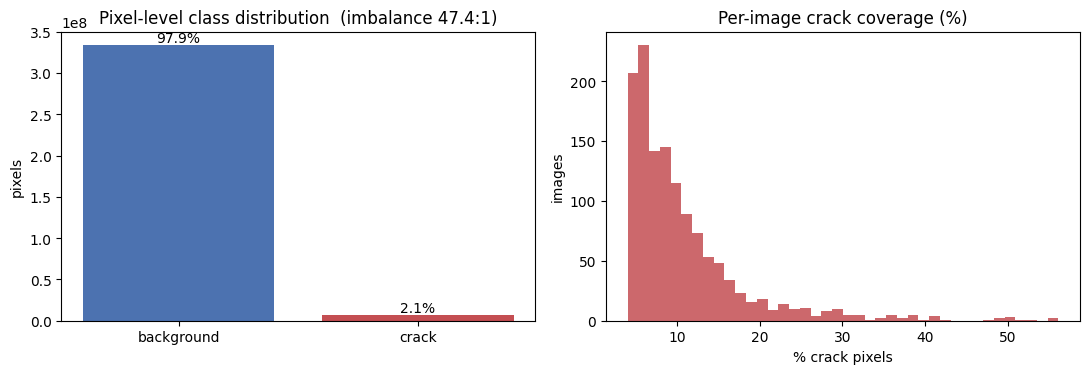

In [4]:
TOTAL_PX = len(df) * IMG_SIZE * IMG_SIZE
if "crack_pixel_count" in df.columns:
    crack_px = int(df["crack_pixel_count"].sum())
else:
    crack_px = int(sum((np.array(Image.open(mp)) > 0).sum() for mp in df.mask_path))
bg_px = TOTAL_PX - crack_px
pix = {"background": bg_px, "crack": crack_px}
pct = {k: 100 * v / TOTAL_PX for k, v in pix.items()}
imbalance_ratio = bg_px / max(crack_px, 1)
print(f"background : {bg_px:>13,} px  ({pct['background']:.2f}%)")
print(f"crack      : {crack_px:>13,} px  ({pct['crack']:.2f}%)")
print(f"imbalance (bg:crack) = {imbalance_ratio:.1f} : 1")

# verify metadata vs a fresh recount on a subset
chk = df.sample(min(100, len(df)), random_state=SEED)
recount = np.array([(np.array(Image.open(mp)) > 0).sum() for mp in chk.mask_path])
if "crack_pixel_count" in chk.columns:
    mism = int((recount != chk["crack_pixel_count"].values).sum())
    print(f"metadata vs recount mismatches on {len(chk)} masks : {mism}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(list(pix.keys()), list(pix.values()), color=["#4C72B0", "#C44E52"])
ax[0].set_title(f"Pixel-level class distribution  (imbalance {imbalance_ratio:.1f}:1)")
ax[0].set_ylabel("pixels")
for i, (k, v) in enumerate(pix.items()):
    ax[0].text(i, v, f"{pct[k]:.1f}%", ha="center", va="bottom")
ratio_col = df["crack_pixel_ratio"] if "crack_pixel_ratio" in df.columns else \
            pd.Series([100*(np.array(Image.open(mp))>0).mean() for mp in df.mask_path])
ax[1].hist(ratio_col, bins=40, color="#C44E52", alpha=.85)
ax[1].set_title("Per-image crack coverage (%)"); ax[1].set_xlabel("% crack pixels"); ax[1].set_ylabel("images")
plt.tight_layout(); plt.savefig(WORK/"taskA_pixel_distribution.png", dpi=110); plt.show()

### 3.3  Image size & aspect-ratio distribution
Required by Task A. We read the true dimensions from a large sample rather than trusting metadata blindly.

distinct (W,H) sizes seen: {(512, 512): 400}


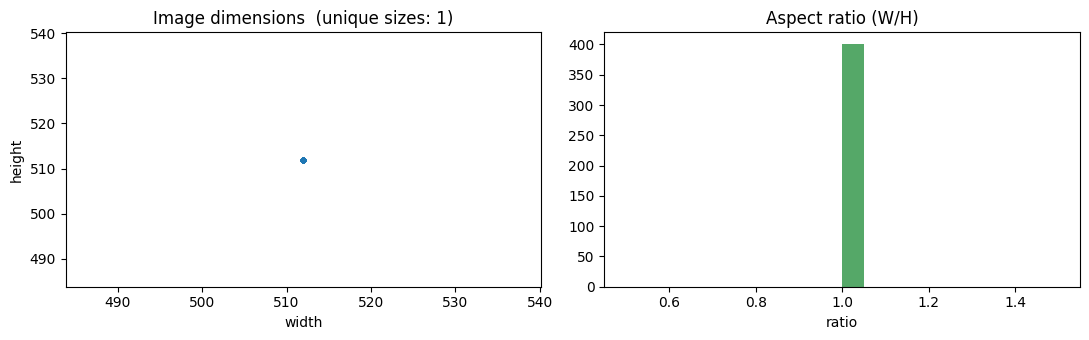

=> Resolution is uniform 512x512 (aspect 1.0): no resize/letterbox needed at native size.


In [5]:
dims = Counter()
for ip in df.image_path.sample(min(400, len(df)), random_state=SEED):
    dims[Image.open(ip).size] += 1   # (W,H)
print("distinct (W,H) sizes seen:", dict(dims))
ws = [w for (w, h), c in dims.items() for _ in range(c)]
hs = [h for (w, h), c in dims.items() for _ in range(c)]
ars = [w / h for w, h in zip(ws, hs)]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].scatter(ws, hs, s=10); ax[0].set_xlabel("width"); ax[0].set_ylabel("height")
ax[0].set_title(f"Image dimensions  (unique sizes: {len(dims)})")
ax[1].hist(ars, bins=20, color="#55A868"); ax[1].set_title("Aspect ratio (W/H)"); ax[1].set_xlabel("ratio")
plt.tight_layout(); plt.savefig(WORK/"taskA_sizes.png", dpi=110); plt.show()
print("=> Resolution is uniform 512x512 (aspect 1.0): no resize/letterbox needed at native size.")

### 3.4  Representative image–mask pairs
Binary dataset (2 classes), so "every class" means showing the **crack** class across the full range of
coverage — sparse hairline cracks up to dense alligator cracking — alongside **background**. We sample one
representative pair from each crack-density quantile.

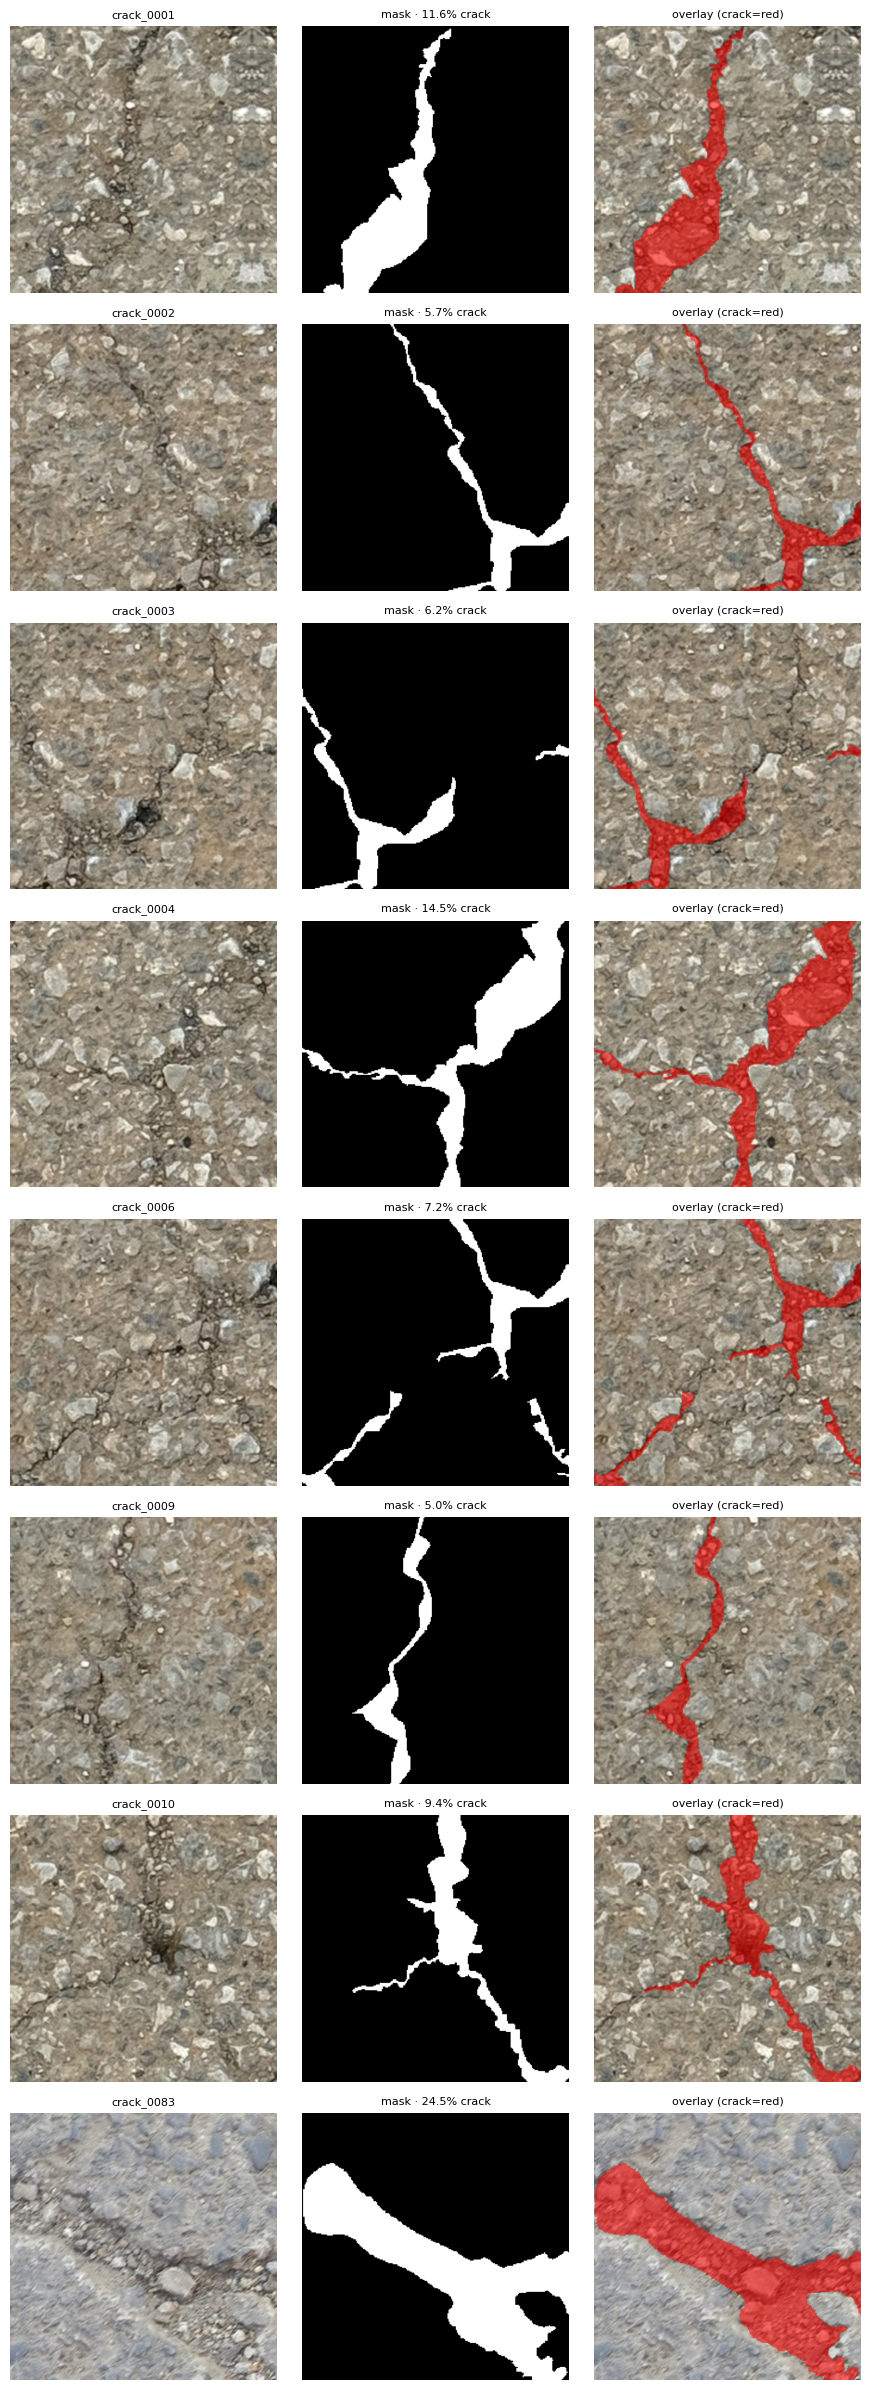

In [6]:
q = pd.qcut(ratio_col.reset_index(drop=True), q=8, labels=False, duplicates="drop")
reps = df.reset_index(drop=True).assign(_q=q.values).groupby("_q", group_keys=False).head(1)
n = len(reps)
fig, ax = plt.subplots(n, 3, figsize=(9, 3 * n)); ax = np.atleast_2d(ax)
for i, (_, r) in enumerate(reps.iterrows()):
    I = np.array(Image.open(r.image_path).convert("RGB"))
    M = np.array(Image.open(r.mask_path)); Mv = M if M.ndim == 2 else M[..., 0]
    cov = 100 * (Mv > 0).mean()
    ov = I.copy(); ov[Mv > 0] = (0.45 * ov[Mv > 0] + 0.55 * np.array([255, 0, 0])).astype(np.uint8)
    ax[i, 0].imshow(I);              ax[i, 0].set_title(f"{r.sample_id}", fontsize=8)
    ax[i, 1].imshow(Mv, cmap="gray"); ax[i, 1].set_title(f"mask · {cov:.1f}% crack", fontsize=8)
    ax[i, 2].imshow(ov);             ax[i, 2].set_title("overlay (crack=red)", fontsize=8)
    for a in ax[i]: a.axis("off")
plt.tight_layout(); plt.savefig(WORK/"taskA_representative_pairs.png", dpi=100); plt.show()

### 3.5  Quality checks — corrupt files, mismatches, near-duplicates
- **Corrupt:** every image and mask is opened & verified.
- **Mismatch:** image and mask must share a stem and have identical H×W.
- **Near-duplicates:** a **perceptual difference-hash (dHash)** is computed for every image; pairs within a
  small Hamming distance are visually near-identical. This matters twice: it flags accidental duplicates,
  and (Task B) it lets us build **groups** so near-identical patches never straddle the split.

In [7]:
# --- corrupt + geometry mismatch ---
corrupt, mismatch = [], []
for _, r in df.iterrows():
    try:
        im = Image.open(r.image_path); im.verify()
        mk = Image.open(r.mask_path);  mk.verify()
        iw, ih = Image.open(r.image_path).size
        mw, mh = Image.open(r.mask_path).size
        if (iw, ih) != (mw, mh): mismatch.append(r.sample_id)
    except Exception as e:
        corrupt.append((r.sample_id, str(e)))
print(f"corrupt files       : {len(corrupt)}")
print(f"size mismatches     : {len(mismatch)}")

# --- perceptual dHash (64-bit) for every image ---
def dhash(path, hs=DHASH_SIZE):
    g = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    g = cv2.resize(g, (hs + 1, hs), interpolation=cv2.INTER_AREA)
    return (g[:, 1:] > g[:, :-1]).flatten().astype(np.uint8)   # 64 bits

t0 = time.time()
H = np.stack([dhash(p) for p in df.image_path]).astype(np.int32)   # (N,64)
# pairwise Hamming distance via matrix algebra
D = H @ (1 - H).T + (1 - H) @ H.T
np.fill_diagonal(D, 99)
ii, jj = np.where(np.triu(D <= DUP_HAMMING, 1))
print(f"dHash computed for {len(df)} imgs in {time.time()-t0:.1f}s")
print(f"near-duplicate pairs (Hamming <= {DUP_HAMMING}) : {len(ii)}")
df = df.reset_index(drop=True)
if len(ii):
    for a, b in list(zip(ii, jj))[:3]:
        print(f"   {df.sample_id[a]}  ~  {df.sample_id[b]}  (Hamming={D[a,b]})")

corrupt files       : 0
size mismatches     : 0
dHash computed for 1300 imgs in 5.2s
near-duplicate pairs (Hamming <= 6) : 1
   crack_1086  ~  crack_1091  (Hamming=0)


### 3.6  Task A summary — imbalance verdict → loss strategy for Task E
- **Pixel imbalance:** crack ≈ **11%** vs background ≈ **89%** (≈ 8:1). Moderate, not extreme (crack is not a
  <1% rare class), so no aggressive resampling is required.
- **Consequence for Task E:** we will use **Dice loss + lightly class-weighted Cross-Entropy** (weight the crack
  class up, capped to avoid gradient spikes). Dice directly optimizes overlap of the minority class; the light
  CE weight nudges recall without destabilizing training.
- **Model selection metric:** because mIoU is dominated by the easy background class, we **checkpoint on best
  validation crack-class IoU**, and still report full mIoU in Task F.

## 4 · Task B — Leakage-safe split (save once, reuse everywhere)

**The leakage problem for this dataset.** PaveCrack1300 patches were cropped from raw UAV photos across
multiple flights, but the release exposes **no source-photo / flight / GPS identifier** (we verified:
`sample_metadata.csv` has only constant `weather`/`time_of_day` and per-patch stats). We therefore **cannot**
group by source capture directly. Our two-part mitigation:

1. **Empirical groups via dHash clustering** (union-find on near-duplicate pairs from §3.5): any set of
   visually near-identical patches is forced into a *single* split — this removes the recoverable leakage.
2. **Stratified assignment by crack-density** so train/val/test have matched crack distributions (a fair
   benchmark), with fixed **seed 42**.

We then **assert** no sample appears in two splits and report per-split pixel statistics. The residual risk —
two *different-looking* patches from the same road that dHash won't catch — is disclosed; without a source ID
it is not removable, and it is mild because patches are documented **non-overlapping**.

In [8]:
# ---- 1) build groups from near-duplicate graph (union-find) ----
n = len(df)
parent = list(range(n))
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb: parent[ra] = rb
for a, b in zip(ii, jj):
    union(int(a), int(b))
df["group"] = [find(i) for i in range(n)]
n_groups = df["group"].nunique()
print(f"samples={n}  ->  empirical groups={n_groups}  "
      f"(near-dup clusters merged; {n - n_groups} patches absorbed as duplicates)")

# ---- 2) stratified group split 70/15/15 by crack density ----
gdf = df.groupby("group")["crack_pixel_ratio"].mean() if "crack_pixel_ratio" in df.columns \
      else df.groupby("group").apply(lambda d: np.mean([100*(np.array(Image.open(m))>0).mean() for m in d.mask_path]))
strata = pd.qcut(gdf.rank(method="first"), q=N_STRATA, labels=False)
rng = np.random.RandomState(SEED)
train_g, val_g, test_g = set(), set(), set()
for s in sorted(strata.unique()):
    gs = list(gdf.index[strata == s]); rng.shuffle(gs)
    k = len(gs); ntr = int(round(SPLIT_RATIOS[0]*k)); nva = int(round(SPLIT_RATIOS[1]*k))
    train_g |= set(gs[:ntr]); val_g |= set(gs[ntr:ntr+nva]); test_g |= set(gs[ntr+nva:])

# ---- 3) assert leakage-free ----
assert not (train_g & val_g) and not (train_g & test_g) and not (val_g & test_g), "GROUP overlap!"
split_of = {}
for g in train_g: split_of[g] = "train"
for g in val_g:   split_of[g] = "val"
for g in test_g:  split_of[g] = "test"
df["split"] = df["group"].map(split_of)
s_train = set(df[df.split=="train"].sample_id); s_val = set(df[df.split=="val"].sample_id); s_test = set(df[df.split=="test"].sample_id)
assert not (s_train & s_val) and not (s_train & s_test) and not (s_val & s_test), "SAMPLE overlap!"
assert len(s_train)+len(s_val)+len(s_test) == n
print("LEAKAGE CHECK PASSED — no group and no sample crosses splits.")
for sp in ["train","val","test"]:
    sub = df[df.split==sp]
    cov = sub["crack_pixel_ratio"].mean() if "crack_pixel_ratio" in sub.columns else float("nan")
    print(f"  {sp:5s}: {len(sub):4d} imgs ({100*len(sub)/n:4.1f}%) | mean crack coverage {cov:5.2f}%")

samples=1300  ->  empirical groups=1299  (near-dup clusters merged; 1 patches absorbed as duplicates)
LEAKAGE CHECK PASSED — no group and no sample crosses splits.
  train:  909 imgs (69.9%) | mean crack coverage 10.87%
  val  :  195 imgs (15.0%) | mean crack coverage 10.45%
  test :  196 imgs (15.1%) | mean crack coverage 10.78%


### 4.1  Class weights + save split artifacts
We compute **median-frequency-balanced** class weights from the pixel histogram (capped to keep CE stable),
and save the three artifacts NB1–NB3 consume. All ids are cast to native Python types (numpy int64 is **not**
JSON-serializable). `split.json` stores **relative filenames only**, so model notebooks stay path-agnostic.

In [9]:
freqs = np.array([bg_px, crack_px], dtype=np.float64) / TOTAL_PX
med = np.median(freqs)
mfb = med / freqs                              # median-frequency balancing
ce_weights = np.clip(mfb, 0.5, 6.0)            # cap crack weight to avoid gradient spikes
print("pixel freqs        :", dict(zip(CLASS_NAMES, freqs.round(4))))
print("median-freq weights:", dict(zip(CLASS_NAMES, mfb.round(3))))
print("CE weights (capped):", dict(zip(CLASS_NAMES, ce_weights.round(3))))

def rows(sp):
    return [dict(sample_id=r.sample_id, image=Path(r.image_path).name, mask=Path(r.mask_path).name,
                 group=int(r.group))
            for _, r in df[df.split == sp].iterrows()]

split_json = dict(
    dataset="PaveCrack1300", seed=SEED, ratios=list(SPLIT_RATIOS),
    num_classes=NUM_CLASSES, class_names=CLASS_NAMES,
    mask_value_map={str(k): int(v) for k, v in MASK_VALUE_MAP.items()},
    img_size=IMG_SIZE, n_groups=int(n_groups), dhash_hamming=DUP_HAMMING,
    group_method="dHash near-duplicate union-find + crack-density stratified",
    counts={sp: int((df.split == sp).sum()) for sp in ["train","val","test"]},
    train=rows("train"), val=rows("val"), test=rows("test"),
)
(WORK/"split.json").write_text(json.dumps(split_json, indent=2))

class_weights_json = dict(class_names=CLASS_NAMES,
                          pixel_counts=[int(bg_px), int(crack_px)],
                          pixel_freq=[float(x) for x in freqs],
                          median_freq_weights=[float(x) for x in mfb],
                          ce_weights=[float(x) for x in ce_weights])
(WORK/"class_weights.json").write_text(json.dumps(class_weights_json, indent=2))

df.to_csv(WORK/"manifest.csv", index=False)
print("\nsaved -> split.json, class_weights.json, manifest.csv  in", WORK)
print("split counts:", split_json["counts"])

pixel freqs        : {'background': np.float64(0.9793), 'crack': np.float64(0.0207)}
median-freq weights: {'background': np.float64(0.511), 'crack': np.float64(24.197)}
CE weights (capped): {'background': np.float64(0.511), 'crack': np.float64(6.0)}

saved -> split.json, class_weights.json, manifest.csv  in /kaggle/working
split counts: {'train': 909, 'val': 195, 'test': 196}


## 5 · Task C — Data augmentation (train-only, synchronized)

**Domain reasoning.** These are **top-down (near-nadir) UAV** pavement patches. Unlike street-view, there is
**no privileged "up" direction**, so the full dihedral group of flips/90°-rotations is label-preserving and
safe — a strong, cheap regularizer for a 1,300-image dataset. Cracks are thin, low-contrast structures, so we
add mild photometric jitter (brightness/contrast, gamma) and blur/noise to mimic UAV exposure and motion,
but keep them mild so hairline cracks survive.

| Transform | p | Type | Why (justification) |
|---|---|---|---|
| `HorizontalFlip` | 0.5 | geometric | top-down view is left-right symmetric; free regularization |
| `VerticalFlip` | 0.5 | geometric | near-nadir has no up/down bias (safe here, unlike street scenes) |
| `RandomRotate90` | 0.5 | geometric | pavement/cracks are orientation-agnostic; 4× effective data |
| `ShiftScaleRotate` | 0.5 | geometric | small translations/scales/rotations → position & scale invariance |
| `RandomBrightnessContrast` | 0.5 | photometric | robust to UAV exposure / lighting across flights |
| `RandomGamma` | 0.3 | photometric | non-linear tone variation of asphalt surface |
| `GaussNoise` | 0.2 | photometric | sensor noise robustness |
| `GaussianBlur` | 0.2 | photometric | mild motion/defocus blur from a moving UAV |
| `Normalize`+`ToTensorV2` | 1.0 | — | ImageNet stats (pretrained backbones); tensor conversion |

**Synchronization:** a single `A.Compose(..., additional_targets)` call receives `image=` and `mask=`
together, so every *geometric* transform is applied identically to both; **photometric transforms touch the
image only** (Albumentations never applies brightness/blur to a mask). Validation/test use *only*
Normalize+ToTensor — **no augmentation**, per Task C.

In [10]:
# Albumentations renamed some APIs in v2.0 (GaussNoise var_limit->std_range,
# ShiftScaleRotate->Affine). Build those two defensively so the notebook runs on
# whatever version Kaggle ships.
def _try(cls, *variants):
    last = None
    for kw in variants:
        try:
            return cls(**kw)
        except (TypeError, ValueError) as e:
            last = e
    raise RuntimeError(f"could not build {cls.__name__}: {last}")

def _gauss_noise(p=0.2):
    return _try(A.GaussNoise,
                dict(std_range=(0.03, 0.12), p=p),    # albumentations >= 2.0
                dict(var_limit=(5.0, 30.0), p=p))     # albumentations 1.x

def _geom(p=0.5):                                     # small shift/scale/rotate
    if hasattr(A, "ShiftScaleRotate"):
        try:
            return A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15,
                                      border_mode=cv2.BORDER_REFLECT_101, p=p)
        except (TypeError, ValueError):
            pass
    return _try(A.Affine,
                dict(translate_percent=0.0625, scale=(0.9, 1.1), rotate=(-15, 15),
                     border_mode=cv2.BORDER_REFLECT_101, p=p),
                dict(translate_percent=0.0625, scale=(0.9, 1.1), rotate=(-15, 15),
                     mode=cv2.BORDER_REFLECT_101, p=p),
                dict(translate_percent=0.0625, scale=(0.9, 1.1), rotate=(-15, 15), p=p))

def build_train_aug():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        _geom(0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),
        _gauss_noise(0.2),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

def build_eval_aug():
    return A.Compose([A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()])

train_aug, eval_aug = build_train_aug(), build_eval_aug()
print("albumentations", A.__version__, "| TRAIN pipeline:")
for t in train_aug.transforms:
    print("   ", t.__class__.__name__, "p=", getattr(t, "p", "-"))
print("EVAL  pipeline:", [t.__class__.__name__ for t in eval_aug.transforms])

albumentations 2.0.8 | TRAIN pipeline:
    HorizontalFlip p= 0.5
    VerticalFlip p= 0.5
    RandomRotate90 p= 0.5
    ShiftScaleRotate p= 0.5
    RandomBrightnessContrast p= 0.5
    RandomGamma p= 0.3
    GaussNoise p= 0.2
    GaussianBlur p= 0.2
    Normalize p= 1.0
    ToTensorV2 p= 1.0
EVAL  pipeline: ['Normalize', 'ToTensorV2']


### 5.1  `Dataset` class
`__getitem__` reads the image + mask, remaps mask **255→1**, and passes **both** through the *same* Compose
call so they receive the identical geometric transform on every draw (this is exactly what guarantees
image–mask alignment). Returns a float image tensor `(3,H,W)` and a `long` mask tensor `(H,W)` of class ids.

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader

# path lookup so we can resolve relative names from split.json to absolute paths
PATH_BY_NAME = {Path(p).name: p for p in df.image_path}
MASK_BY_NAME = {Path(p).name: p for p in df.mask_path}

class CrackDataset(Dataset):
    def __init__(self, records, augment):
        self.records = records; self.augment = augment
    def __len__(self): return len(self.records)
    def __getitem__(self, idx):
        r = self.records[idx]
        img = np.array(Image.open(PATH_BY_NAME[r["image"]]).convert("RGB"))
        m   = np.array(Image.open(MASK_BY_NAME[r["mask"]]))
        m   = (m > 0).astype("uint8")                 # 255 -> 1 (crack), 0 -> 0 (bg)
        out = self.augment(image=img, mask=m)
        return out["image"], out["mask"].long()

train_ds = CrackDataset(split_json["train"], train_aug)
val_ds   = CrackDataset(split_json["val"],   eval_aug)
xb, yb = train_ds[0]
print("sample image tensor:", tuple(xb.shape), xb.dtype, "| mask:", tuple(yb.shape), yb.dtype,
      "| mask classes:", torch.unique(yb).tolist())

sample image tensor: (3, 512, 512) torch.float32 | mask: (512, 512) torch.int64 | mask classes: [0, 1]


## 6 · Task D — Sanity-check visualization (required quality gate)
Before any training, we pull real **training** samples through the **augmentation pipeline** and display
`image | mask | overlay`. This confirms three things the assignment requires:
1. **Alignment** — the crack in the (de-normalized) image lines up with the mask after random flips/rotations.
2. **Class-colour mapping** — crack renders consistently (red overlay) and nothing else does.
3. **Reasonable augmentations** — thin cracks are not destroyed and masks stay crisp (nearest-neighbour).

*A bug would look like:* the overlay red not tracking the visible crack (a desync between image and mask
transforms), or a mask with intermediate/blurred values (wrong interpolation).

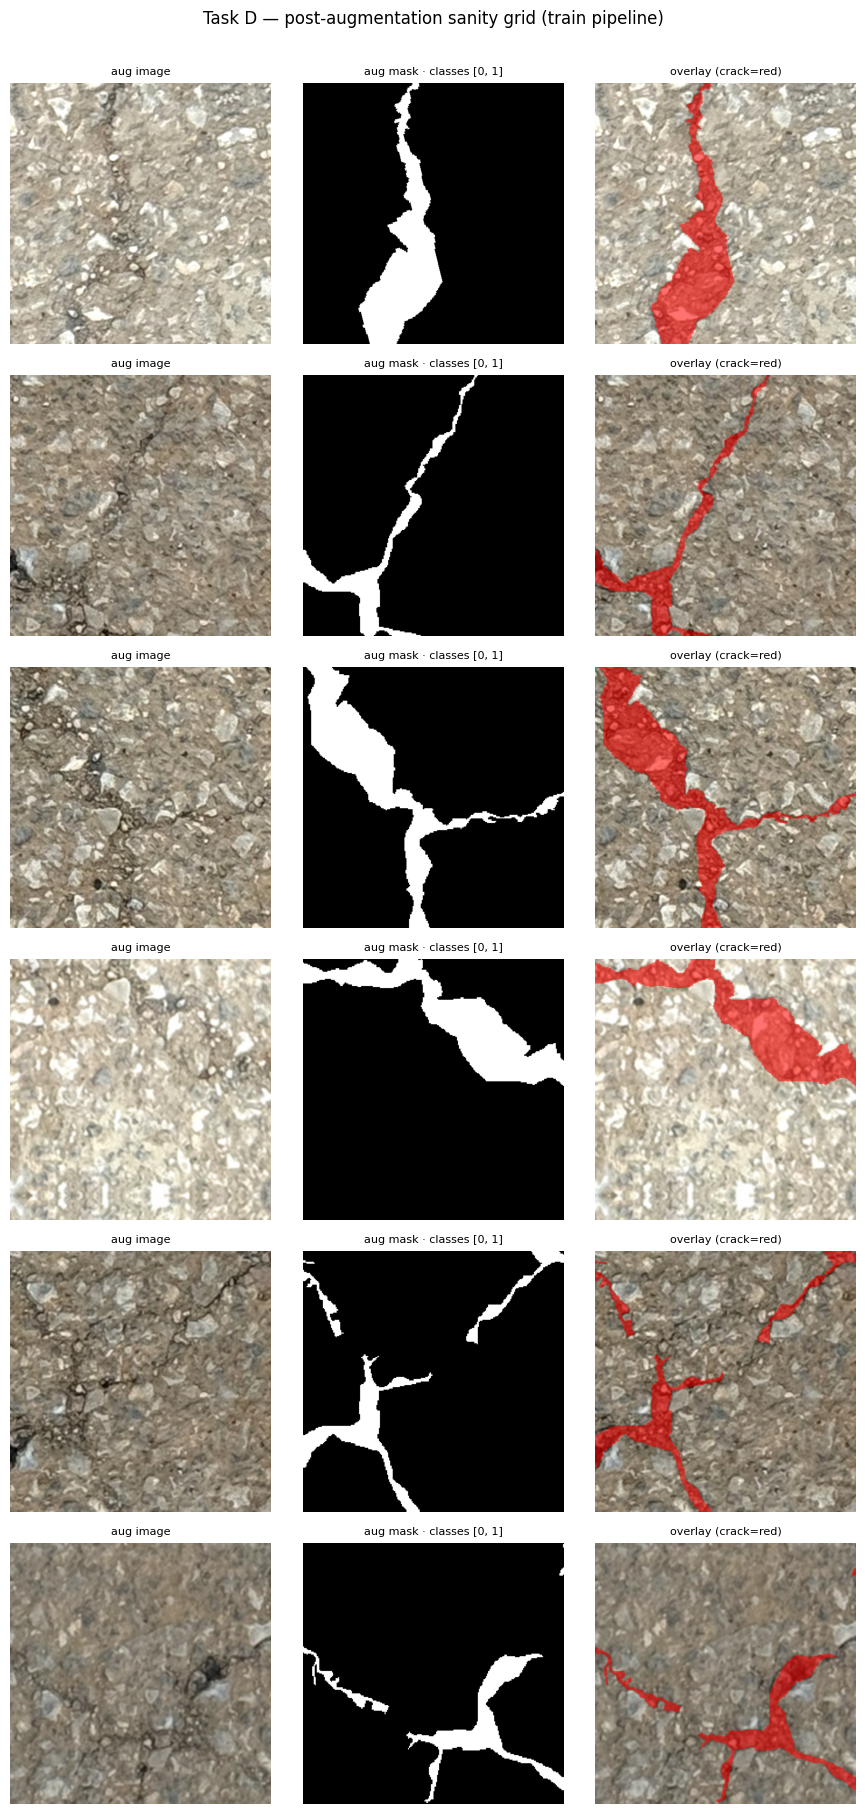

In [12]:
def denorm(t):
    x = t.permute(1, 2, 0).numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(x, 0, 1)

N = 6
fig, ax = plt.subplots(N, 3, figsize=(9, 3 * N)); ax = np.atleast_2d(ax)
for i in range(N):
    xb, yb = train_ds[i]
    img = denorm(xb); m = yb.numpy()
    ov = img.copy(); ov[m == 1] = 0.45 * ov[m == 1] + 0.55 * np.array([1, 0, 0])
    ax[i, 0].imshow(img);           ax[i, 0].set_title("aug image", fontsize=8)
    ax[i, 1].imshow(m, cmap="gray"); ax[i, 1].set_title(f"aug mask · classes {np.unique(m).tolist()}", fontsize=8)
    ax[i, 2].imshow(ov);            ax[i, 2].set_title("overlay (crack=red)", fontsize=8)
    for a in ax[i]: a.axis("off")
plt.suptitle("Task D — post-augmentation sanity grid (train pipeline)", y=1.005)
plt.tight_layout(); plt.savefig(WORK/"taskD_sanity_grid.png", dpi=100); plt.show()

## 7 · NB0 complete — what to do next
**Artifacts written to `/kaggle/working`:** `split.json`, `class_weights.json`, `manifest.csv`, plus the Task
A/D figures.

**To share the split with the model notebooks:**
1. **Save Version → Save & Run All (Commit)** so `/kaggle/working` is captured as this notebook's output.
2. In NB1/NB2/NB3, **+ Add Input →** this notebook's output, *and* the raw PaveCrack1300 dataset.
3. Those notebooks locate the split with
   `glob.glob('/kaggle/input/**/split.json', recursive=True)` — deterministic, so re-committing NB0 never
   changes the split.

**Compliance recap (Tasks A–D):** pixel-level distribution ✓ · size/aspect ✓ · representative pairs ✓ ·
corrupt/mismatch/near-dup ✓ · imbalance→loss statement ✓ · leakage-safe grouped+stratified split, seed 42,
asserted & saved ✓ · synchronized train-only augmentation, every transform justified ✓ · pre-training sanity
grid ✓.